# 🎵 End-to-End Regression Pipeline (Deep Learning) — *YearPredictionMSD*

**Tujuan:** memprediksi **tahun rilis lagu** (continuous target) dari **90 fitur audio** (timbre) menggunakan **deep learning (PyTorch MLP)**.

**Komponen pipeline (sesuai requirement tugas):**
| # | Tahap | Tools |
|---|-------|-------|
| 1 | Data loading & EDA | pandas, matplotlib, seaborn |
| 2 | Cleaning & preprocessing (missing values, outliers, scaling) | scikit-learn |
| 3 | Model deep learning (MLP) | PyTorch |
| 4 | Hyperparameter tuning | **Optuna** |
| 5 | Evaluation (MSE, RMSE, MAE, R²) | scikit-learn |
| 6 | Interpretasi hasil | **LIME** |
| 7 | Experiment tracking | **MLflow** |

> **Cara pakai:** set `DATA_PATH` ke file `midterm-regresi-dataset.csv`, dan *Run All*.
> Kalau file belum ada, notebook otomatis pakai **data sintetis** (struktur sama) supaya tetap bisa jalan untuk demo. Set `QUICK=False` untuk hasil maksimal.

## 0. Setup & Konfigurasi

`QUICK=True` → cepat (untuk test). `QUICK=False` → trial & epoch lebih banyak (untuk hasil final).

In [1]:
import os, time, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import optuna
import mlflow
from lime.lime_tabular import LimeTabularExplainer

# ---------- reproducibility ----------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- KONFIGURASI ----------
DATA_PATH   = "midterm-regresi-dataset.csv"   # data
QUICK       = False          # True = cepat untuk test; False = hasil final
N_TRIALS    = 8   if QUICK else 40    # jumlah trial Optuna
TUNE_EPOCHS = 20  if QUICK else 80    # epoch per trial saat tuning
FINAL_EPOCHS= 50  if QUICK else 200   # epoch model final
PATIENCE    = 10                      # early-stopping patience

sns.set_style("whitegrid")
print("Device:", DEVICE, "| torch", torch.__version__, "| QUICK =", QUICK)

Device: cpu | torch 2.12.1+cpu | QUICK = False


## 1. Load Dataset

Loader di bawah **otomatis mendeteksi** apakah CSV punya header atau tidak (dataset MSD asli **tanpa header**, kolom pertama = tahun). Kolom dinamai `year`, `feature_1 ... feature_N`.

Kalau file tidak ditemukan → fallback ke **data sintetis** yang meniru struktur MSD (90 fitur, target tahun 1922–2011), lengkap dengan missing values & outliers untuk menguji tahap cleaning.

In [2]:
def make_synthetic(n=4000, n_features=90, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n, n_features))
    w = np.zeros(n_features); idx = rng.choice(n_features, 20, replace=False)
    w[idx] = rng.normal(0, 1.5, size=20)
    sig = X @ w; sig = (sig - sig.mean())/sig.std()
    year = np.clip(np.round(1985 + 14*sig + rng.normal(0, 4, n)), 1922, 2011).astype(int)
    cols = ["year"] + [f"feature_{i}" for i in range(1, n_features+1)]
    df = pd.DataFrame(np.column_stack([year, X]), columns=cols); df["year"] = df["year"].astype(int)
    for c in rng.choice(cols[1:], 5, replace=False):           # inject missing
        df.loc[df.sample(frac=0.02, random_state=1).index, c] = np.nan
    for c in rng.choice(cols[1:], 3, replace=False):           # inject outliers
        df.loc[df.sample(frac=0.005, random_state=2).index, c] *= 50
    return df

def load_dataset(path):
    if not os.path.exists(path):
        print(f"[!] '{path}' tidak ditemukan -> pakai DATA SINTETIS untuk demo.")
        return make_synthetic()
    probe = pd.read_csv(path, header=None, nrows=5)
    first_row_numeric = pd.to_numeric(probe.iloc[0], errors="coerce").notna().all()
    df = pd.read_csv(path, header=(None if first_row_numeric else 0))
    df.columns = ["year"] + [f"feature_{i}" for i in range(1, df.shape[1])]
    print(f"[ok] Loaded '{path}' (header={'tidak ada' if first_row_numeric else 'ada'})")
    return df

df = load_dataset(DATA_PATH)
print("Shape:", df.shape)
df.head()

[ok] Loaded 'midterm-regresi-dataset.csv' (header=tidak ada)
Shape: (515345, 91)


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


## 2. Exploratory Data Analysis (EDA)

Memeriksa: ringkasan statistik, jumlah missing values, distribusi target (tahun), dan korelasi fitur terhadap target.

In [3]:
TARGET = "year"
print("=== Info dasar ===")
print("Jumlah baris :", len(df))
print("Jumlah fitur :", df.shape[1]-1)
print("Missing total:", int(df.isna().sum().sum()))
print("Duplikat     :", int(df.duplicated().sum()))
print("\nRentang tahun:", int(df[TARGET].min()), "-", int(df[TARGET].max()))
df.describe().T.head(8)

=== Info dasar ===
Jumlah baris : 515345
Jumlah fitur : 90
Missing total: 0
Duplikat     : 214

Rentang tahun: 1922 - 2011


,count,mean,std,min,25%,50%,75%,max
year,515345.0,1998.397082,10.931046,1922.00000,1994.00000,2002.00000,2006.00000,2011.00000
feature_1,515345.0,43.387126,6.067558,1.74900,39.95469,44.25850,47.83389,61.97014
feature_2,515345.0,1.289554,51.580351,-337.09250,-26.05952,8.41785,36.12401,384.06573
feature_3,515345.0,8.658347,35.268585,-301.00506,-11.46271,10.47632,29.76482,322.85143
feature_4,515345.0,1.164124,16.322790,-154.18358,-8.48750,-0.65284,8.78754,335.77182
feature_5,515345.0,-6.553601,22.860785,-181.95337,-20.66645,-6.00777,7.74187,262.06887
feature_6,515345.0,-9.521975,12.857751,-81.79429,-18.44099,-11.18839,-2.38896,166.23689
feature_7,515345.0,-2.391089,14.571873,-188.21400,-10.78060,-2.04667,6.50858,172.40268


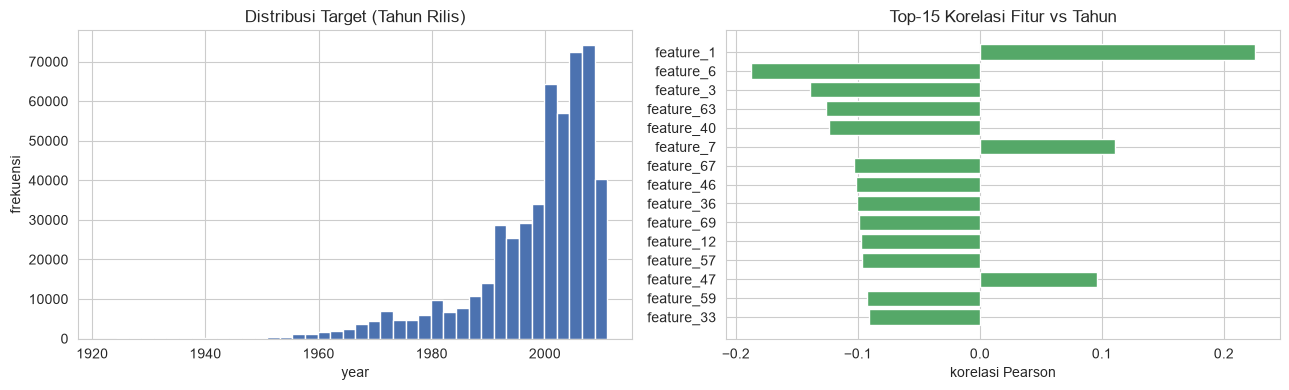

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df[TARGET], bins=40, color="#4C72B0", edgecolor="white")
ax[0].set_title("Distribusi Target (Tahun Rilis)"); ax[0].set_xlabel("year"); ax[0].set_ylabel("frekuensi")

# korelasi tiap fitur terhadap target (top-15 absolut)
corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
top = corr.head(15)
ax[1].barh(top.index[::-1], top.values[::-1], color="#55A868")
ax[1].set_title("Top-15 Korelasi Fitur vs Tahun"); ax[1].set_xlabel("korelasi Pearson")
plt.tight_layout(); plt.show()

## 3. Data Cleaning & Preprocessing

Langkah (semua di-*fit* hanya pada data **train** agar bebas *data leakage*):
1. **Drop duplikat**.
2. **Split** train / validation / test (64% / 16% / 20%).
3. **Missing values** → imputasi **median** (robust terhadap outlier).
4. **Outliers** → **winsorize** (clip ke persentil 1–99 dari train) — menjaga jumlah data, bukan menghapus baris.
5. **Scaling fitur** → `StandardScaler` (penting agar MLP konvergen).
6. **Scaling target** → tahun di-standardisasi saat training, lalu di-*inverse* untuk evaluasi/interpretasi (membuat NN konvergen jauh lebih cepat).

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
X = df.drop(columns=[TARGET]); y = df[TARGET].astype(float)
feat_names = X.columns.tolist()

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.20, random_state=SEED)

# 1) impute (median)  2) clip outliers  3) scale  — params dari TRAIN saja
imputer = SimpleImputer(strategy="median").fit(X_tr)
lo = np.nanpercentile(imputer.transform(X_tr), 1, axis=0)
hi = np.nanpercentile(imputer.transform(X_tr), 99, axis=0)

def prep(Xdf, scaler=None):
    a = np.clip(imputer.transform(Xdf), lo, hi)
    return scaler.transform(a) if scaler is not None else a

scaler = StandardScaler().fit(prep(X_tr))
Xtr, Xva, Xte = prep(X_tr, scaler), prep(X_va, scaler), prep(X_te, scaler)

# scale target (train/val); test target dibiarkan di skala tahun asli
yscaler = StandardScaler().fit(y_tr.values.reshape(-1, 1))
yscale   = lambda v: yscaler.transform(np.asarray(v).reshape(-1,1)).ravel().astype(np.float32)
yunscale = lambda v: yscaler.inverse_transform(np.asarray(v).reshape(-1,1)).ravel()
ytr, yva = yscale(y_tr.values), yscale(y_va.values)
yte = y_te.values.astype(np.float32)

print("train:", Xtr.shape, "| val:", Xva.shape, "| test:", Xte.shape)

train: (329683, 90) | val: (82421, 90) | test: (103027, 90)


## 4. Model Deep Learning — Multi-Layer Perceptron (PyTorch)

Arsitektur: beberapa `Linear → BatchNorm → ReLU → Dropout`, ditutup `Linear(…, 1)`.
Training pakai **Adam + MSE loss + early stopping** pada validation set.

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, dropout):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

def make_loader(Xa, ya, bs, shuffle):
    ds = TensorDataset(torch.tensor(Xa, dtype=torch.float32),
                       torch.tensor(ya, dtype=torch.float32))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

def train_model(hidden, dropout, lr, wd, bs, epochs, patience=PATIENCE, track=False):
    model = MLP(Xtr.shape[1], hidden, dropout).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.MSELoss()
    tl = make_loader(Xtr, ytr, bs, True)
    Xva_t = torch.tensor(Xva, dtype=torch.float32).to(DEVICE)
    yva_t = torch.tensor(yva, dtype=torch.float32).to(DEVICE)
    best, best_state, bad, hist = np.inf, None, 0, []
    for ep in range(epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(): vloss = lossf(model(Xva_t), yva_t).item()
        if track: hist.append(vloss)
        if vloss < best - 1e-4:
            best, best_state, bad = vloss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state: model.load_state_dict(best_state)
    return (model, best, hist) if track else (model, best)

def predict(model, Xa):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(Xa, dtype=torch.float32).to(DEVICE)).cpu().numpy()

def predict_year(model, Xa):  # kembalikan prediksi dalam SKALA TAHUN
    return yunscale(predict(model, Xa))

print("Model & helper siap.")

Model & helper siap.


## 5. Hyperparameter Tuning — Optuna (+ tracking MLflow)

Optuna mencari kombinasi terbaik: jumlah layer, jumlah unit, dropout, learning rate, weight decay, batch size. **Objektif = minimkan validation RMSE** (skala tahun). Setiap trial dicatat sebagai *nested run* di **MLflow**.

In [7]:
mlflow.set_experiment("year_prediction_dl")

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden   = [trial.suggest_categorical(f"u{i}", [64, 128, 256]) for i in range(n_layers)]
    dropout  = trial.suggest_float("dropout", 0.0, 0.4)
    lr       = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    wd       = trial.suggest_float("wd", 1e-6, 1e-3, log=True)
    bs       = trial.suggest_categorical("bs", [128, 256, 512])
    with mlflow.start_run(nested=True):
        mlflow.log_params(dict(n_layers=n_layers, hidden=hidden, dropout=dropout, lr=lr, wd=wd, bs=bs))
        model, _ = train_model(hidden, dropout, lr, wd, bs, TUNE_EPOCHS)
        vrmse = float(np.sqrt(mean_squared_error(y_va.values, predict_year(model, Xva))))
        mlflow.log_metric("val_rmse", vrmse)
    return vrmse

optuna.logging.set_verbosity(optuna.logging.WARNING)
t0 = time.time()
with mlflow.start_run(run_name="optuna_search"):
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
    mlflow.log_metric("best_val_rmse", study.best_value)

print(f"\nSelesai dalam {time.time()-t0:.1f}s")
print("Best val RMSE :", round(study.best_value, 3), "tahun")
print("Best params   :", study.best_params)

2026/06/23 22:37:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/23 22:37:22 INFO mlflow.store.db.utils: Updating database tables
2026/06/23 22:37:23 INFO mlflow.tracking.fluent: Experiment with name 'year_prediction_dl' does not exist. Creating a new experiment.
2026/06/23 22:37:23 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn

  0%|          | 0/40 [00:00<?, ?it/s]


Selesai dalam 9525.4s
Best val RMSE : 8.421 tahun
Best params   : {'n_layers': 3, 'u0': 256, 'u1': 256, 'u2': 64, 'dropout': 0.17954224879855074, 'lr': 0.00010224129283498934, 'wd': 1.0742202793936408e-05, 'bs': 256}


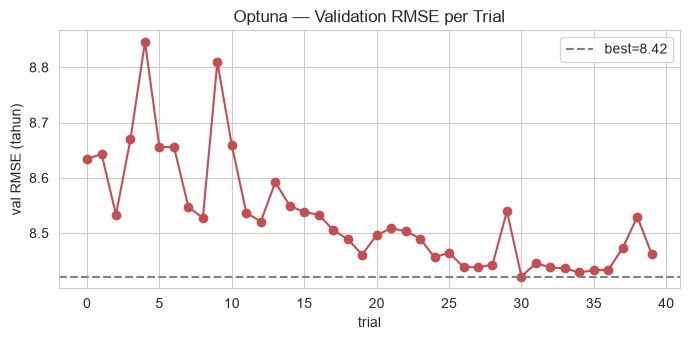

In [8]:
# Visualisasi ringkas hasil tuning
hist_df = study.trials_dataframe()[["number", "value"]].rename(columns={"value": "val_rmse"})
plt.figure(figsize=(7,3.5))
plt.plot(hist_df["number"], hist_df["val_rmse"], "o-", color="#C44E52")
plt.axhline(study.best_value, ls="--", color="gray", label=f"best={study.best_value:.2f}")
plt.title("Optuna — Validation RMSE per Trial"); plt.xlabel("trial"); plt.ylabel("val RMSE (tahun)")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Training Model Final (best hyperparameters)

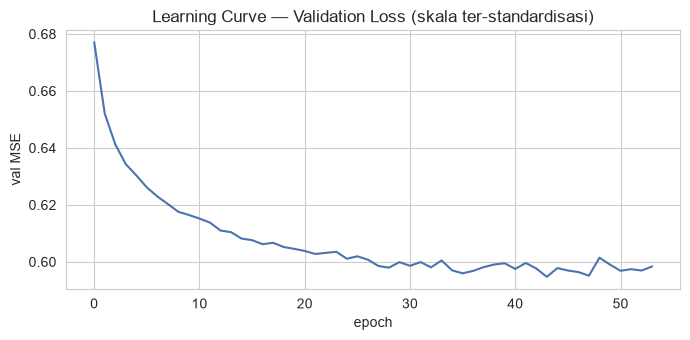

Epoch terlatih: 54


In [9]:
bp = study.best_params
hidden = [bp[f"u{i}"] for i in range(bp["n_layers"])]
final_model, _, hist = train_model(hidden, bp["dropout"], bp["lr"], bp["wd"], bp["bs"],
                                   FINAL_EPOCHS, track=True)

plt.figure(figsize=(7,3.5))
plt.plot(hist, color="#4C72B0")
plt.title("Learning Curve — Validation Loss (skala ter-standardisasi)")
plt.xlabel("epoch"); plt.ylabel("val MSE"); plt.tight_layout(); plt.show()
print("Epoch terlatih:", len(hist))

## 7. Evaluation — MSE, RMSE, MAE, R²

Dihitung pada **test set** (skala tahun asli). Plus **plot prediksi vs aktual** dan **residual**, serta perbandingan dengan **baseline ML (Ridge & Random Forest)**.

In [10]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MSE": mse, "RMSE": float(np.sqrt(mse)),
            "MAE": mean_absolute_error(y_true, y_pred), "R2": r2_score(y_true, y_pred)}

# --- Deep Learning ---
pred_dl = predict_year(final_model, Xte)
m_dl = regression_metrics(yte, pred_dl)

# --- Baseline ML (latih pada fitur ter-scale, target asli) ---
ridge = Ridge(alpha=1.0).fit(Xtr, y_tr.values)
m_ridge = regression_metrics(yte, ridge.predict(Xte))
rf = RandomForestRegressor(n_estimators=(60 if QUICK else 200), n_jobs=-1, random_state=SEED).fit(Xtr, y_tr.values)
m_rf = regression_metrics(yte, rf.predict(Xte))

comp = pd.DataFrame({"MLP (Deep Learning)": m_dl, "Ridge": m_ridge, "Random Forest": m_rf}).T
print("=== Perbandingan Model (Test Set) ==="); display(comp.round(4))

# --- log metrik DL ke MLflow + simpan model ---
with mlflow.start_run(run_name="final_model"):
    mlflow.log_params(bp)
    mlflow.log_metrics(m_dl)
    try:
        try:    mlflow.pytorch.log_model(final_model, name="model", input_example=Xte[:3].astype(np.float32))
        except TypeError: mlflow.pytorch.log_model(final_model, artifact_path="model", input_example=Xte[:3].astype(np.float32))
    except Exception as e: print("(model artifact logging dilewati:", e, ")")
print("Metrik DL tercatat di MLflow.")

=== Perbandingan Model (Test Set) ===


,MSE,RMSE,MAE,R2
MLP (Deep Learning),71.2551,8.4413,5.7748,0.3945
Ridge,88.4221,9.4033,6.7155,0.2487
Random Forest,82.0284,9.0570,6.4785,0.3030


Metrik DL tercatat di MLflow.


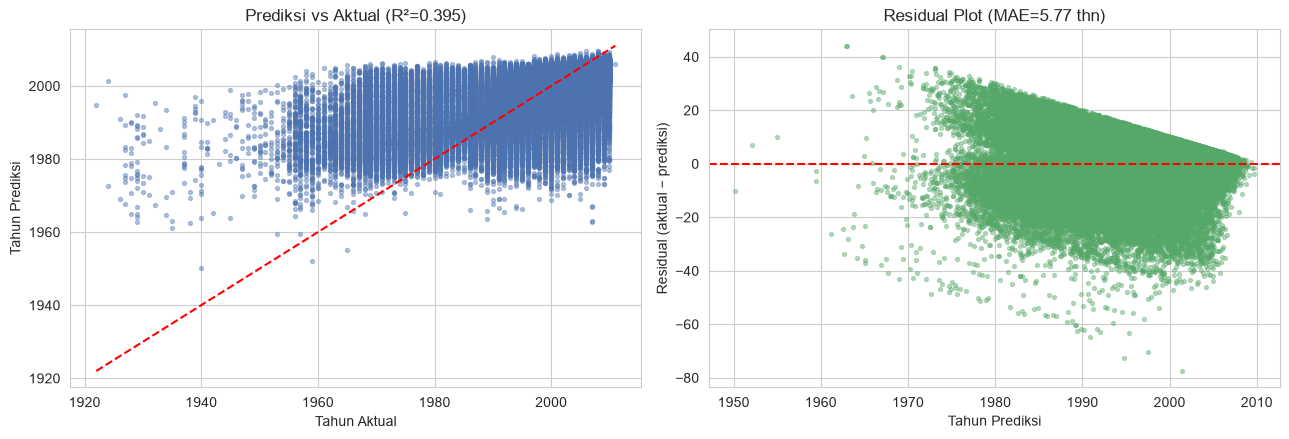

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(yte, pred_dl, s=8, alpha=0.4, color="#4C72B0")
lims = [min(yte.min(), pred_dl.min()), max(yte.max(), pred_dl.max())]
ax[0].plot(lims, lims, "r--"); ax[0].set_xlabel("Tahun Aktual"); ax[0].set_ylabel("Tahun Prediksi")
ax[0].set_title(f"Prediksi vs Aktual (R²={m_dl['R2']:.3f})")

resid = yte - pred_dl
ax[1].scatter(pred_dl, resid, s=8, alpha=0.4, color="#55A868")
ax[1].axhline(0, color="r", ls="--"); ax[1].set_xlabel("Tahun Prediksi"); ax[1].set_ylabel("Residual (aktual − prediksi)")
ax[1].set_title(f"Residual Plot (MAE={m_dl['MAE']:.2f} thn)")
plt.tight_layout(); plt.show()

## 8. Interpretasi Hasil — LIME

LIME menjelaskan **prediksi per-instance**: fitur mana yang paling mendorong prediksi tahun naik/turun untuk satu lagu tertentu. Explainer dilatih pada distribusi data train, mode `regression`.

Instance #0 | aktual = 1975 | prediksi = 1998.1



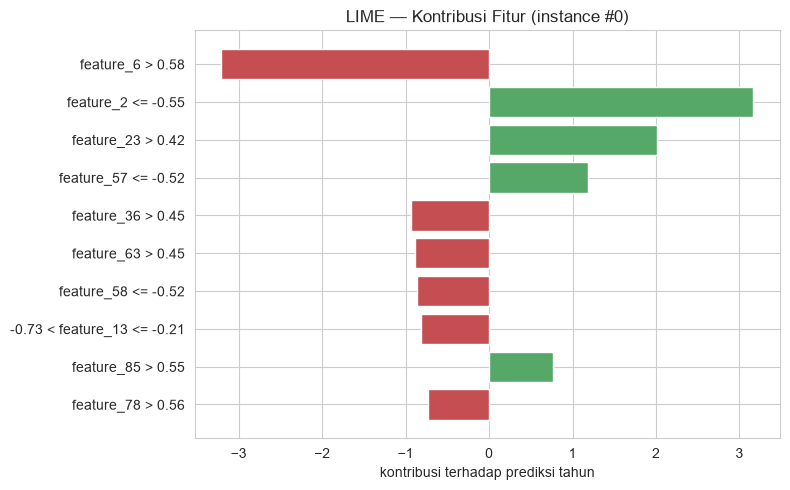

In [12]:
explainer = LimeTabularExplainer(
    training_data=Xtr, feature_names=feat_names, mode="regression",
    discretize_continuous=True, random_state=SEED)

def lime_predict(arr): return predict_year(final_model, arr.astype(np.float32))

idx = 0  # ganti index untuk menjelaskan lagu lain
exp = explainer.explain_instance(Xte[idx], lime_predict, num_features=10)
print(f"Instance #{idx} | aktual = {yte[idx]:.0f} | prediksi = {pred_dl[idx]:.1f}\n")

pairs = exp.as_list()
labels = [p[0] for p in pairs][::-1]; vals = [p[1] for p in pairs][::-1]
colors = ["#C44E52" if v < 0 else "#55A868" for v in vals]
plt.figure(figsize=(8, 5))
plt.barh(labels, vals, color=colors)
plt.title(f"LIME — Kontribusi Fitur (instance #{idx})")
plt.xlabel("kontribusi terhadap prediksi tahun"); plt.tight_layout(); plt.show()

## 9. Interpretasi & Kesimpulan

**Ringkasan metrik (test set)** ada di tabel perbandingan Section 7. Cara membaca:
- **RMSE / MAE** dalam satuan **tahun** — makin kecil makin baik. Pada dataset MSD asli, RMSE neural network yang baik biasanya berkisar **~9–10 tahun** (dataset ini memang sulit; banyak lagu beda tahun punya timbre mirip).
- **R²** menunjukkan proporsi variansi tahun yang dijelaskan model (0–1, makin tinggi makin baik).
- **MLP vs baseline:** bandingkan apakah deep learning mengungguli Ridge/Random Forest. Kalau selisih tipis, itu wajar — fitur timbre punya hubungan yang sebagian besar linear-lemah dengan tahun.

**Catatan metodologis (penting untuk laporan):**
- Dataset MSD asli punya *"producer effect"* — lagu dari artis yang sama bisa bocor antar train/test. Split resmi menyarankan **463.715 baris pertama untuk train, 51.630 terakhir untuk test**. Notebook ini pakai `train_test_split` acak; kalau mau ikut split resmi, ganti bagian Section 3.
- **MLflow:** jalankan `mlflow ui` di terminal (folder yang sama) lalu buka `http://127.0.0.1:5000` untuk melihat semua run, parameter, dan metrik.

**Saran peningkatan:** tambah trial Optuna (`QUICK=False`), coba arsitektur lebih dalam / residual connections, feature selection berbasis korelasi, atau ensemble MLP + Random Forest.

In [13]:
print("RINGKASAN AKHIR")
print("="*40)
print("Best hyperparameters:", study.best_params)
print(f"\nDeep Learning (MLP) — Test:")
for k, v in m_dl.items(): print(f"  {k:5s}: {v:.4f}")
print("\nJalankan `mlflow ui` untuk melihat tracking lengkap.")

RINGKASAN AKHIR
Best hyperparameters: {'n_layers': 3, 'u0': 256, 'u1': 256, 'u2': 64, 'dropout': 0.17954224879855074, 'lr': 0.00010224129283498934, 'wd': 1.0742202793936408e-05, 'bs': 256}

Deep Learning (MLP) — Test:
  MSE  : 71.2551
  RMSE : 8.4413
  MAE  : 5.7748
  R2   : 0.3945

Jalankan `mlflow ui` untuk melihat tracking lengkap.
